# Orientation

## Frame of reference

The IMU has its own frame (denoted with subscript/superscript $s$ for sensor), which is defined by the orientation of its sensors, and it's drawn on the front of component. On the first version of the prototype, it's mounted on the perfboard as follows:

<img src="./frames/sensor.png" alt="Hardware body frame" width="200" height="250">

The origin is assumed to be at roughly the center of the IMU.

However, this application will use the following right-handed system of coordinates (x: right, y: forwards, z: up) for the body frame (denoted with subscript/superscript $b$ for body):

<img src="./frames/body.jpg" alt="Software body frame" width="250" height="250">

The origin still lies at center of the sensor, which is, at the same time, roughly at the center of the device, mounted on the chest of the user. 

The world frame (denoted with subscript/superscript $w$ for world), independent of the device, can be thought as local (i.e. tangent to the Earth's surface near the location of the device) and earth-fixed (i.e. rotates with earth, despite looking stationary from the perspective of the device), but it is only partially observable. The z-axis is defined pointing upwards but still aligned with the direction of gravity, and the x and y axes are orthogonal to it and between each other, but their orientation is not defined. The body frame and world frame are generally not aligned. The acceleration due to gravity is assumed to be constant. 

The goal of this notebook is to compute the orientation of the device with respect to the world frame, given the measurements from the IMU, to later subtract the gravity vector from the measured acceleration. 

## Rotations in 3D space: Euler angles

Euler angles were chosen because they are the most straightforward approach and easier to understand. They can be thought of as rotating an object around the x, y, and z axes, one at a time and creating intermediate frames, in a specific sequence. This yields, in the end, a complete orientation of the object in 3D space. They are *active* transformations.

Coordinate transformations (*passive* transformations) of a point in space, moving from one frame to another, can be represented by pre-multiplying a column vector by a matrix. For this application, it's of interest to move from the world frame to the body frame and viceversa:

$$
\bm{x}^{w} = \bm{C}^{w}_{b} \bm{x}^{b} \\
\bm{x}^{b} = \bm{C}^{b}_{w} \bm{x}^{w}
$$
*Note*: read the subscript as the "from" frame and the superscript as the "to" frame. 

Active and passive tranformations are related and, in fact, the opposite of each other: an active rotation of a vector in a fixed frame is equivalent to a passive rotation of the frame in the opposite direction with the vector fixed. In the rest of this notebook, passive transformations will be used. 

Euler angles can be represented by matrices. If $\phi$ is the roll angle (i.e., rotation around the x axis), $\theta$ is the pitch angle (i.e. rotation around y axis), and $\psi$ is the yaw angle (i.e. rotation around z axis), the passive transformation matrices for roll, pitch and yaw rotations are defined as follows:
$$
\bm{C}_{w,x}^{b}(\phi_{wb}) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi_{wb} & \sin\phi_{wb} \\
0 & -\sin\phi_{wb} & \cos\phi_{wb}
\end{bmatrix}
$$
$$
\bm{C}_{w,y}^{b}(\theta_{wb}) = \begin{bmatrix}
\cos\theta_{wb} & 0 & -\sin\theta_{wb} \\
0 & 1 & 0 \\
\sin\theta_{wb} & 0 & \cos\theta_{wb}
\end{bmatrix}
$$
$$
\bm{C}_{w,z}^{b}(\psi_{wb}) = \begin{bmatrix}
\cos\psi_{wb} & \sin\psi_{wb} & 0 \\
-\sin\psi_{wb} & \cos\psi_{wb} & 0 \\
0 & 0 & 1
\end{bmatrix}
$$
These matrices can be combined in different orders to represent a complete rotation in space. The order matters because matrix multiplication is not commutative. A common convention is to perform a right-handed rotation (i.e. aligning the thumb with the axis, rotation follows the direction of the fingers when curling them) around z axis (yaw), then around the y axis (pitch), and finally around the x axis (roll). The combined rotation matrix is given by:
$$
\bm{C}_{w}^{b} = \bm{C}_{w,x}^{b}(\phi_{wb}) \bm{C}_{w,y}^{b}(\theta_{wb}) \bm{C}_{w,z}^{b}(\psi_{wb}) = \begin{bmatrix}
\cos\theta_{wb} \cos\psi_{wb} & \cos\theta_{wb} \sin\psi_{wb} & - \sin\theta_{wb} \\
-\cos\phi_{wb} \sin\psi_{wb} + \sin\phi_{wb} \sin\theta_{wb} \cos\psi_{wb} & \cos\phi_{wb} \cos\psi_{wb} + \sin\phi_{wb} \sin\theta_{wb} \sin\psi_{wb} & \sin\phi_{wb} \cos\theta_{wb} \\
\sin\phi_{wb} \sin\psi_{wb} + \cos\phi_{wb} \sin\theta_{wb} \cos\psi_{wb} & - \sin\phi_{wb} \cos\psi_{wb} + \cos\phi_{wb} \sin\theta_{wb} \sin\psi_{wb} & \cos\phi_{wb} \cos\theta_{wb}
\end{bmatrix}
$$
*Note*: reversing the operation would be done with $\bm{C}_{b}^{w} = (\bm{C}_{w}^{b})^{-1} = (\bm{C}_{w}^{b})^T = \bm{C}_{w,z}^{b}(-\psi_{wb}) \bm{C}_{w,y}^{b}(-\theta_{wb}) \bm{C}_{w,x}^{b}(-\phi_{wb})$.

If $\bm{g}^{w} = [0, 0, -g]^T$ is the gravity vector in the world frame, where $g = 9.80665 \text{ m/s}^2$, then the gravity vector in the body frame is given by:
$$
\bm{g}^{b} = \bm{C}_{w}^{b} \bm{g}^{w} = \begin{bmatrix}
g \sin\theta_{wb} \\
-g \cos\theta_{wb} \sin\phi_{wb} \\
-g \cos\theta_{wb} \cos\phi_{wb}
\end{bmatrix}
$$ 
The accelerometer measures the specific force acting on the device, which is the non-gravitational force per unit of mass on a body:
$$
\bm{f}_{ib} = \bm{a}_{ib} - \bm{\gamma}_{ib}
$$
where $\bm{a}_{b}^{i}$ is the acceleration of the body with respect to an inertial frame, and $\bm{\gamma}^{b}$ is the gravitational force (not to be confused with $\bm{g}^{b}$, which is the acceleration *due* to gravity). However, when the device is stationary:
$$
\bm{f}_{ib} = - \bm{g}^{b} = \begin{bmatrix}
-g \sin\theta_{wb} \\
g \cos\theta_{wb} \sin\phi_{wb} \\
g \cos\theta_{wb} \cos\phi_{wb}
\end{bmatrix}
$$
This equation will be used below to compute the roll and pitch angles from the accelerometer measurements.

## Sensor fusion: complementary filter

### Classical formula

Conceptually, sensor fusion consists on estimating a magnitude (in this case, the roll and pitch) leveraging data from different sensors. The complementary filter is a simple way to do this, based on different characteristics of the sensors:

* Gyroscope: good short-term stability, but drifts in the long term.
* Accelerometer: good long-term stability, but noisy in the short term.

On continuous time, the idea is to apply a low-pass effect on the angle computed from accelerometer data and a high-pass effect on the integrated gyroscope data. On discrete time, the classical formula for the complementary filter is given by:

$$
\phi_{wb,i} = \alpha_{c} \left(\phi_{wb,i-1} + w_{x, i}^{b} \cdot \Delta t\right) + (1 - \alpha_{c}) \phi_{wb,acc} \\
\theta_{wb,i} = \alpha_{c} \left(\theta_{wb,i-1} + w_{y, i}^{b} \cdot \Delta t\right) + (1 - \alpha_{c}) \theta_{wb,acc}
$$

Where $0 < \alpha_{c} = \frac{\tau}{\tau + \Delta t} < 1$ is a tuning parameter, $\tau$ is the time constant of the filter and $\Delta t$ is the sampling period.

To compute the orientation from acceleration data, stationary periods can be used, where the only force acting on the device is gravity. For roll, do:
$$
\frac{a_{y}^{b}}{a_{z}^{b}} = \frac{g \cos\theta_{wb} \sin\phi_{wb}}{g \cos\theta_{wb} \cos\phi_{wb}} \\
\phi_{wb,acc,1} = {atan2}(a_{y}^{b}, a_{z}^{b})
$$
Where $\phi_{wb,acc,1} \in [-180^\circ, 180^\circ]$. For pitch, do: 

$$
(a_{y}^{b})^2 + (a_{z}^{b})^2 = g^2 \cos^2\theta_{wb} (\overbrace{\sin^2\phi_{wb} + \cos^2\phi_{wb}}^{1}) = g^2 \cos^2\theta_{wb} \\
\sqrt{(a_{y}^{b})^2 + (a_{z}^{b})^2} = g |\cos\theta_{wb}| \\
\frac{a_{x}^{b}}{\sqrt{(a_{y}^{b})^2 + (a_{z}^{b})^2}} = \frac{- g \sin\theta_{wb}}{g |\cos\theta_{wb}|}  \\
$$
Let $r = \sqrt{(a_{y}^{b})^2 + (a_{z}^{b})^2}$, then using the definition of the absolute value function and noting that $atan2(y,x) \ne atan2(-y,-x)$, there are two solutions for $\theta_{wb}$:
$$
\theta_{wb,acc,1}= {atan2}(-a_{x}^{b}, r), \text{when } \cos\theta_{wb} \geq 0 \\
\theta_{wb,acc,2}= {atan2}(-a_{x}^{b}, -r), \text{when } \cos\theta_{wb} < 0 \\
$$
Where $\theta_{wb,acc,1} \in [-90^\circ, 90^\circ]$. To find $\phi_{wb,acc, 2}$, consider that acceleration has to be the same independent of angles:
$$
a_{y}^{b} = g \cos\theta_{wb,acc,1} \sin\phi_{wb,acc,1} = g \cos\theta_{wb,acc,2} \sin\phi_{wb,acc,2} \\
a_{z}^{b} = g \cos\theta_{wb,acc,1} \cos\phi_{wb,acc,1} = g \cos\theta_{wb,acc,2} \cos\phi_{wb,acc,2}
$$
The relationship holds provided that:
$$
\cos\phi_{wb,acc,2} = -\cos\phi_{wb,acc,1} = \cos(\phi_{wb,acc,1} + 180^\circ) \\
\sin\phi_{wb,acc,2} = -\sin\phi_{wb,acc,1} = \sin(\phi_{wb,acc,1} + 180^\circ) \\
\phi_{wb,acc,2} = \phi_{wb,acc,1} + 180^\circ \text{wrapped to } [-180^\circ, 180^\circ]
$$
Notice that some strategy must be followed to choose the "closer" solution to fuse with the gyroscope-based estimate. Also notice that the $\psi_{wb}$ angle can't be computed from the accelerometer data, since the rotation around the gravity vector is unobservable from acceleration. Another point of reference, such as a magnetometer, would be needed to compute this angle. Since common calisthenics movements happen mostly on the sagital plane and a minor set on the frontal plane of the human body, the XY plane can be oriented to correspond with the plane of least importance, i.e. the transverse plane. As a reference, the following figure shows the three planes of movement of the human body: 

<img src="../../docs/misc/planes-of-motion-human-body.webp" alt="Coordinate system" width="400" height="300">

The previous formulas assume that gravity is the only force acting on the device, but that is not usually the case in this application. A possible solution involves changing $\alpha_{c}$ to favor the gyroscope data more heavily when the device is in motion, and weigh the accelerometer more when the device is relatively stationary. A simple way to detect stationarity that has been used across notebooks is to check that: 
$$
| ||\bm{a}^{b}|| - \mu_{a^{b}} | \leq k \sigma_{a^{b}} \\
| ||\bm{\omega}^{b}|| - \mu_{\omega^{b}}| \leq k \sigma_{\omega^{b}} 
$$ 
Where $\mu$ and $\sigma$ are the mean and standard deviation of norms of a set of stationary samples and $k$ is chosen so that it spans most stationary samples (e.g. $k = 3$, which covers 99.7% of them according to the empirical rule). More complex methods (e.g. discard samples at the beginning and end of a stationary interval, or requiring a minimum length) have been found to not be suitable because additional conditions may not be met at all with real exercise data.

### Corrected formula

The classical formula has a flaw. On the first term, where gyro is numerically integrated with the Euler's method, it assumes that the "roll", "pitch", and "yaw" rates as measured by the IMU are the Euler angle derivatives:
$$
\frac{d\phi_{wb}}{dt} = \dot \phi_{wb}= w_{x}^{b} \\
\frac{d\theta_{wb}}{dt} = \dot \theta_{wb}= w_{y}^{b} \\
\frac{d\psi_{wb}}{dt} = \dot \psi_{wb}= w_{z}^{b}
$$
But this is not generally true, except for, maybe, small angles or slow dynamics. Euler angles derivatives are related to the IMU angular rates by a non-linear transformation (Euler kinematical equations). The correct relationship is:
$$
\bm{\omega}^{b} = \begin{bmatrix}
1 & 0 & -\sin\theta_{wb} \\
0 & \cos\phi_{wb} & \sin\phi_{wb} \cos\theta_{wb} \\
0 & -\sin\phi_{wb} & \cos\phi_{wb} \cos\theta_{wb}
\end{bmatrix} \cdot \begin{bmatrix}
\dot \phi_{wb} \\
\dot \theta_{wb} \\
\dot \psi_{wb}
\end{bmatrix} = 
\bm{T}(\phi_{wb}, \theta_{wb}) \cdot \bm{\dot \Psi}_{wb} 
$$
Taking the inverse of the above matrix with a CAS:
$$
\bm{\dot \Psi}_{wb} =\bm{T}^{-1}(\phi_{wb}, \theta_{wb}) \cdot \bm{\omega}^{b} = \begin{bmatrix}
1 & \sin\phi_{wb} \tan\theta_{wb} & \cos\phi_{wb} \tan\theta_{wb} \\
0 & \cos\phi_{wb} & -\sin\phi_{wb} \\
0 & \sin\phi_{wb}/\cos\theta_{wb} & \cos\phi_{wb}/\cos\theta_{wb}
\end{bmatrix} \cdot \bm{\omega}^{b}
$$
Notice that this matrix is singular when $\theta_{wb} = \pm 90^\circ$, probably related to gimbal lock (loss of one degree of freedom when the other two rotation axes become aligned). This is a limitation of Euler angles, and as a countermeasure pitch was chosen to correspond with the frontal plane, where the range of motion is much more limited, and roll to correspond with the sagital plane, where the range of motion is much larger. This does not remove the necessity to implement additional checks on the code to prevent division by zero.

The corrected formula for the complementary filter using the true Euler angles and trapezoidal integration instead of Euler integration is then:
$$
\phi_{wb,i} = \alpha_{c} \left(\phi_{wb,i-1} + \frac{\dot \phi_{wb,i-1} + \dot \phi_{wb,i}}{2} \cdot \Delta t\right) + (1 - \alpha_{c}) \phi_{wb,acc} \\
\theta_{wb,i} = \alpha_{c} \left(\theta_{wb,i-1} + \frac{\dot \theta_{wb,i-1} + \dot \theta_{wb,i}}{2} \cdot \Delta t\right) + (1 - \alpha_{c}) \theta_{wb,acc}
$$

Sources:

* [Principles GNSS, Inertial, and Multisensor Integrated Navigation Systems by Paul Groves - Chapter 2](../../docs/misc/Principles%20of%20GNSS,%20Inertial,%20and%20Multisensor%20Integrated%20Navigation%20Systems%20-%20Paul%20Groves.pdf)

* ["The balance filter" by Shane Colton](../../docs/misc/Motion%20filters.pdf)

* ["Using an Accelerometer for inclination sensing" application note by Christopher Fisher](../../docs/misc/Accelerometer%20inclination.pdf)

* [Drone Control and the Complementary Filter by Brian Douglas](https://www.youtube.com/watch?v=whSw42XddsU)

* [Vector Derivatives (the Equation of Coriolis) and the Angular Velocity Vector](https://www.youtube.com/watch?v=-OyRCgv-hPs)

* [Euler Angles and the Euler Rotation Sequence](https://www.youtube.com/watch?v=GJBc6z6p0KQ)

* [Computing Euler Angles: The Euler Kinematical Equations and Poisson’s Kinematical Equations](https://www.youtube.com/watch?v=9GZjtfYOXao)

* [Euler (gimbal lock) Explained](https://www.youtube.com/watch?v=zc8b2Jo7mno)

* [Wikipedia: Gimbal Lock](https://en.wikipedia.org/wiki/Gimbal_lock)

* [Rotation Matrix](https://en.wikipedia.org/wiki/Rotation_matrix)

* [68-95-99.7 Rule](https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule#Table_of_numerical_values)

* [Wikipedia: Specific force](https://en.wikipedia.org/wiki/Specific_force)

* [Wikipedia: List of trigonometric identities](https://en.wikipedia.org/wiki/List_of_trigonometric_identities#Shifts_and_periodicity)

## Setup

In [141]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    IMUStationaryChecker,
)
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats
from functools import reduce

SAMPLING_FREQUENCY = 30  # Hz
dt = 1 / SAMPLING_FREQUENCY
G = 9.80665  # m/s2

sixFaceStationaryCaptures = [
    "../2-noiseReduction/output/pos-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
]
tiltedStationaryCaptures = [
    "../2-noiseReduction/output/pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
]
stationaryCaptures = [*sixFaceStationaryCaptures, *tiltedStationaryCaptures]

simpleRotationsCaptures = [
    "../2-noiseReduction/output/rot-x-hw-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/rot-y-hw-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/rot-z-hw-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
]

realExerciseCaptures = [
    "../2-noiseReduction/output/dips-1-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/dips-2-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/dips-3-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pull-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pull-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pull-ups-3-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/90-deg-push-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/90-deg-push-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
]

reader = IMUSampleReader()
writer = IMUSampleWriter()
stationaryChecker = IMUStationaryChecker()

## Transform sensor frame to body frame

The sensor frame can be transformed to the body frame with a simple linear transformation:

$$
\bm{a}^{b}
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\bm{a}^{s}
$$

$$
\bm{\omega}^{b}
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\bm{\omega}^{s}
$$

or more simply with the following assignments:
$$
a_{y}^{b} = a_{z}^{s} \\
a_{z}^{b} = -a_{y}^{s}
$$
$$
\omega_{y}^{b} = \omega_{z}^{s} \\
\omega_{z}^{b} = -\omega_{y}^{s}
$$

In [142]:
def transformSensorToBodyFrame(a, w):
    aHw = a.copy()
    wHw = w.copy()

    a[:, 0] = aHw[:, 0]
    a[:, 1] = aHw[:, 2]
    a[:, 2] = -aHw[:, 1]

    w[:, 0] = wHw[:, 0]
    w[:, 1] = wHw[:, 2]
    w[:, 2] = -wHw[:, 1]

In [143]:
# Zero
a0 = np.array([[0.0, 0.0, 0.0]])
w0 = np.array([[0.0, 0.0, 0.0]])
transformSensorToBodyFrame(a0, w0)
np.testing.assert_allclose(a0, np.array([[0.0, 0.0, 0.0]]))
np.testing.assert_allclose(w0, np.array([[0.0, 0.0, 0.0]]))

# Base axes
a1 = np.array([[1.0, 0.0, 0.0]])
w1 = np.array([[1.0, 0.0, 0.0]])
transformSensorToBodyFrame(a1, w1)
np.testing.assert_allclose(a1, np.array([[1.0, 0.0, 0.0]]))
np.testing.assert_allclose(w1, np.array([[1.0, 0.0, 0.0]]))

a2 = np.array([[0.0, 1.0, 0.0]])
w2 = np.array([[0.0, 1.0, 0.0]])
transformSensorToBodyFrame(a2, w2)
np.testing.assert_allclose(a2, np.array([[0.0, 0.0, -1.0]]))
np.testing.assert_allclose(w2, np.array([[0.0, 0.0, -1.0]]))

a3 = np.array([[0.0, 0.0, 1.0]])
w3 = np.array([[0.0, 0.0, 1.0]])
transformSensorToBodyFrame(a3, w3)
np.testing.assert_allclose(a3, np.array([[0.0, 1.0, 0.0]]))
np.testing.assert_allclose(w3, np.array([[0.0, 1.0, 0.0]]))

# Right handedness
np.testing.assert_allclose(np.cross(a1[0], a2[0]), a3[0])

## Analyze inverse tangent behavior

`math.atan2(y, x)` (or its vector form, `np.atan2(y, x)`) returns the angle in the interval $[-\pi, \pi]$ between the positive x axis and the point (x,y) in the plane (i.e. the angle of the vector from the origin to (x, y)). It differs from the regular `math.atan(y/x)` because it uses the signs of both arguments to determine the correct quadrant.

$$
\operatorname{atan2}(y,x)=\begin{cases}
\arctan\!\left(\dfrac{y}{x}\right) & x>0\\[6pt]
\arctan\!\left(\dfrac{y}{x}\right)+\pi & x<0,\ y\ge 0\\[6pt]
\arctan\!\left(\dfrac{y}{x}\right)-\pi & x<0,\ y<0\\[6pt]
+\dfrac{\pi}{2} & x=0,\ y>0\\[6pt]
-\dfrac{\pi}{2} & x=0,\ y<0\\[6pt]
\text{undefined} & x=0,\ y=0
\end{cases}
$$

Examples:
- `atan2(1,1) = π/4`  
- `atan2(1,-1) = 3π/4`  
- `atan2(-1,-1) = -3π/4`  
- `atan2(-1,1) = -π/4`  
- `atan2(0,-1) = π`

Problems:

1. The function is vulnerable to rapid oscillations when the angle moves close to the negative x axis (i.e. y close to 0 by excess or defect). To fix this, there are many options, from cheaper/simpler to more complex/expensive:

    * Use a tolerance band within which y = 0 is assigned. The tolerance can't larger than around $0.1-0.2 \, \frac{\text{m}}{\text{s}^2}$, as it would start to filter out real, human scale motions, like the initial phase of a walk, a gentle motion of a vehicle, etc. Also consider interaction the complementary filter's $\alpha_c$: the lower the $\alpha_c$, the lower the tolerance should be, as the accelerometer contribution is larger. This has been tested and it's only a partial solution.

    * Use hysterisis (small non-linearity): the output depends on the current as well as previous inputs and/or the direction of the change. If y is positive and greater than a tolerance, switch to positive. If it's negative and less than a tolerance, switch to negative. Otherwise use a previous state.

    * Unwrap the angle so that it evolves continuously over time. Not necessary for this application. 

    * Leave the function as-is and mitigate the problem elsewhere (chosen option).

2. Some special function evaluations (e.g. involving 0, infinity, NaN) depend on the implementation. 

Sources:

* <https://en.wikipedia.org/wiki/Atan2>

* https://en.wikipedia.org/wiki/Hysteresis

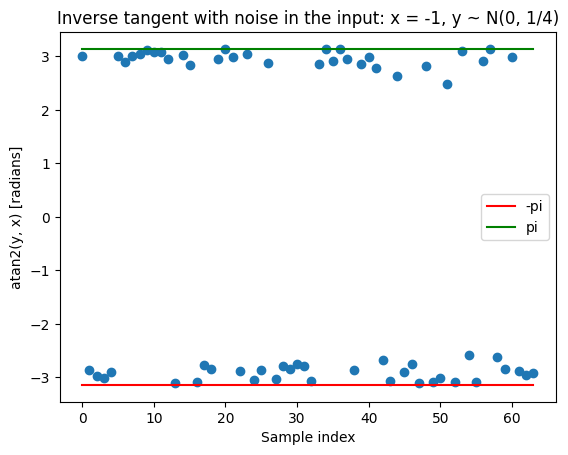

In [144]:
noiseSamples = 64
x = -1 * np.ones(noiseSamples)
y = stats.norm.rvs(loc=0, scale=1 / 4, size=noiseSamples)
plt.plot(np.atan2(y, x), "o")
plt.plot(-np.pi * np.ones(noiseSamples), "r", label="-pi")
plt.plot(np.pi * np.ones(noiseSamples), "g", label="pi")
plt.title("Inverse tangent with noise in the input: x = -1, y ~ N(0, 1/4)")
plt.xlabel("Sample index")
plt.ylabel("atan2(y, x) [radians]")
plt.legend()
plt.show()

In [145]:
print(f"Evaluation of atan2 function for special cases:")
print(f"atan2(1, 0) = {math.atan2(1, 0)}")
print(f"atan2(-1, 0) = {math.atan2(-1, 0)}")
print(f"atan2(0, 0) = {math.atan2(0, 0)}")
print(f"atan2(inf, 1) = {math.atan2(float('inf'), 1)}")
print(f"atan2(-inf, 1) = {math.atan2(float('-inf'), 1)}")
print(f"atan2(inf, -1) = {math.atan2(float('inf'), -1)}")
print(f"atan2(-inf, -1) = {math.atan2(float('-inf'), -1)}")
print(f"atan2(1, inf) = {math.atan2(1, float('inf'))}")
print(f"atan2(1, -inf) = {math.atan2(1, float('-inf'))}")
print(f"atan2(-1, inf) = {math.atan2(-1, float('inf'))}")
print(f"atan2(-1, -inf) = {math.atan2(-1, float('-inf'))}")

Evaluation of atan2 function for special cases:
atan2(1, 0) = 1.5707963267948966
atan2(-1, 0) = -1.5707963267948966
atan2(0, 0) = 0.0
atan2(inf, 1) = 1.5707963267948966
atan2(-inf, 1) = -1.5707963267948966
atan2(inf, -1) = 1.5707963267948966
atan2(-inf, -1) = -1.5707963267948966
atan2(1, inf) = 0.0
atan2(1, -inf) = 3.141592653589793
atan2(-1, inf) = -0.0
atan2(-1, -inf) = -3.141592653589793


In [146]:
# def modAtan2(y, x):
#     accelTol = 0.15
#     if abs(y) > accelTol:
#         return math.atan2(y, x)
#     else:
#         return math.atan2(0, x)


def modAtan2(y, x):
    return math.atan2(y, x)

## Estimate angles from accelerometer data

Euler-angles decomposition of gravity is ambiguous. For every instant, there are the two possible solutions for roll and pitch as was mentioned above. Both the main and the alternative solutions will be computed and one will be chosen to be fused based on similarity with the gyro-based orientation.

In [ ]:
def computeAccelAngleCandidates(a):
    r = math.sqrt(a[1] ** 2 + a[2] ** 2)

    roll1 = 180.0 / np.pi * modAtan2(a[1], a[2])
    pitch1 = 180.0 / np.pi * modAtan2(-a[0], r)

    roll2 = wrapDegrees(roll1 + 180.0)
    pitch2 = 180.0 / np.pi * modAtan2(-a[0], -r)

    return np.array([roll1, pitch1]), np.array([roll2, pitch2])


# Maps an angle to the range [-180, 180] degrees
def wrapDegrees(angle):
    return (angle + 180.0) % 360.0 - 180.0
    # return math.fmod(angle + 180.0, 360.0) - 180.0  // May be better for floating point, but results differ


def wrapRadians(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

To test this, use the physical IMU. Begin at resting position (z up, y pointing to the observer, x to the left), then pitch, then roll, trying to get to the final position. Alternatively, starting from the final position, take the output angles, flip the signs, then roll, then pitch, and verify the device ends up on the resting position. Use the right hand rule extensively and rotate strictly by the frame angles. To make it easier, hold the device on the air and move around it instead of "yawing" it. Don't forget that the input vector is the specific force, NOT the gravity vector, so it points in the opposite direction of gravity.

Testing docs: https://numpy.org/doc/stable/reference/routines.testing.html

In [148]:
angles1, angles2 = computeAccelAngleCandidates(np.array([G, 0.0, 0.0]))
np.testing.assert_allclose(angles1, np.array([0.0, -90.0]))
np.testing.assert_allclose(
    angles2, np.array([-180.0, -90.0])
)  # roll can be any value (singularity/gimbal lock)

angles1, angles2 = computeAccelAngleCandidates(np.array([0.0, G, 0.0]))
np.testing.assert_allclose(angles1, np.array([90.0, 0.0]))
np.testing.assert_allclose(angles2, np.array([-90.0, -180.0]))  # pitch=+-180

angles1, angles2 = computeAccelAngleCandidates(np.array([0.0, 0.0, G]))
np.testing.assert_allclose(angles1, np.array([0.0, 0.0]))  # do nothing
np.testing.assert_allclose(angles2, np.array([-180.0, -180.0]))  # roll,pitch=+-180

angles1, angles2 = computeAccelAngleCandidates(
    np.array([G / math.sqrt(2), 0.0, G / math.sqrt(2)])
)
np.testing.assert_allclose(angles1, np.array([0.0, -45.0]))
np.testing.assert_allclose(angles2, np.array([-180.0, -135.0]))  # roll+-=180

angles1, angles2 = computeAccelAngleCandidates(
    np.array([0.0, G / math.sqrt(2), G / math.sqrt(2)])
)
np.testing.assert_allclose(angles1, np.array([45.0, 0.0]))
np.testing.assert_allclose(angles2, np.array([-135.0, -180.0]))  # pitch=+-180

## Estimate angles from gyroscope data

Compute orientation both by simple integration and with the non-linear transformation to compare the estimates. 

Use initial conditions from the accelerometer solution. Notice than the homogeneous solution is not always correct, since I may have started recording on a different position than neutral (sensor strapped to the chest). 

In [ ]:
integrateEuler = lambda previous, slopeBeginning, step: previous + slopeBeginning * step
integrateTrapezoid = (
    lambda previous, slopeBeginning, slopeEnd, step: previous
    + (slopeBeginning + slopeEnd) * step / 2
)


def gyroOnlyOrientationDirectIntegration(a, w, dt):
    pseudoEulerAnglesGyro = np.zeros_like(w)
    angles1, _ = computeAccelAngleCandidates(a[0, :])
    pseudoEulerAnglesGyro[0, 0] = angles1[0]
    pseudoEulerAnglesGyro[0, 1] = angles1[1]
    for i in range(1, pseudoEulerAnglesGyro.shape[0]):
        pseudoEulerAnglesGyro[i, :] = integrateEuler(
            pseudoEulerAnglesGyro[i - 1, :], w[i, :], dt
        )

    return pseudoEulerAnglesGyro


def gyroOnlyOrientationNonLinearTransform(a, w, dt):
    eulerAnglesGyro = np.zeros_like(w)
    angles1, _ = computeAccelAngleCandidates(a[0, :])
    eulerAnglesGyro[0, 0] = angles1[0]
    eulerAnglesGyro[0, 1] = angles1[1]
    eulerRates = computeEulerRates(eulerAnglesGyro[0, :], w[0, :])
    for i in range(1, eulerAnglesGyro.shape[0]):
        prevEulerRates = eulerRates
        eulerRates = computeEulerRates(eulerAnglesGyro[i - 1, :], w[i, :])
        eulerAnglesGyro[i, :] = integrateTrapezoid(
            eulerAnglesGyro[i - 1, :], prevEulerRates, eulerRates, dt
        )

    return eulerAnglesGyro


def computeEulerRates(prevEulerAngle, w):
    rollRad = math.radians(prevEulerAngle[0])
    pitchRad = math.radians(prevEulerAngle[1])
    Tinv = np.array(
        [
            [
                1,
                math.sin(rollRad) * math.sin(pitchRad) / modCos(pitchRad),
                math.cos(rollRad) * math.sin(pitchRad) / modCos(pitchRad),
            ],
            [0, math.cos(rollRad), -math.sin(rollRad)],
            [
                0,
                math.sin(rollRad) / modCos(pitchRad),
                math.cos(rollRad) / modCos(pitchRad),
            ],
        ]
    )
    return Tinv @ w


SINGULARITY_SAFETY_TOL = 7.5  # deg


# Replaces singularity area with values at the edges of the tolerance band.
# Otherwise behave like the common cosine function
def modCos(x, safetyTol=math.radians(SINGULARITY_SAFETY_TOL)):
    xWrapped = wrapRadians(x)
    if np.pi / 2.0 - safetyTol < abs(xWrapped) <= np.pi / 2.0:
        return math.cos(np.pi / 2.0 - safetyTol)
    elif np.pi / 2.0 < abs(xWrapped) < np.pi / 2.0 + safetyTol:
        return math.cos(np.pi / 2.0 + safetyTol)
    return math.cos(xWrapped)

In [ ]:
safeBand = reduce(
    np.union1d,
    (
        np.arange(-180, -90 - SINGULARITY_SAFETY_TOL),
        np.arange(-90 + SINGULARITY_SAFETY_TOL, 90 - SINGULARITY_SAFETY_TOL),
        np.arange(90 + SINGULARITY_SAFETY_TOL, 180),
    ),
)

assert not math.isclose(
    modCos(math.radians(90)), 0.0
), f"modCos(90deg) is too close to 0"
assert not math.isclose(
    modCos(math.radians(-90)), 0.0
), f"modCos(-90deg) is too close to 0"
for x in safeBand:
    assert math.isclose(
        modCos(math.radians(x)), math.cos(math.radians(x))
    ), f"modCos({x}deg) != cos({x}deg)"

# Verify the invariant T @ T^(-1) = I indirectly for regular Euler angle ranges.
# Assertions are memoryless (they do not depend on previous computations).
getT = lambda rollRad, pitchRad: np.array(
    [
        [1, 0, -math.sin(pitchRad)],
        [0, math.cos(rollRad), math.sin(rollRad) * math.cos(pitchRad)],
        [0, -math.sin(rollRad), math.cos(rollRad) * math.cos(pitchRad)],
    ]
)
rollDeg = 0.0
w = np.array([1.0, 1.0, 1.0])
for pitchDeg in safeBand:
    eulerRates = computeEulerRates(np.array([rollDeg, pitchDeg]), w)
    np.testing.assert_allclose(
        getT(math.radians(rollDeg), math.radians(pitchDeg)) @ eulerRates, w
    )

Study singularity area graphically to assess the behavior of the transformation matrix.

*Conclusion*: the values stay bounded, but this is not the cleanest fix. A large tolerance may be safer but sacrifices accuracy. 

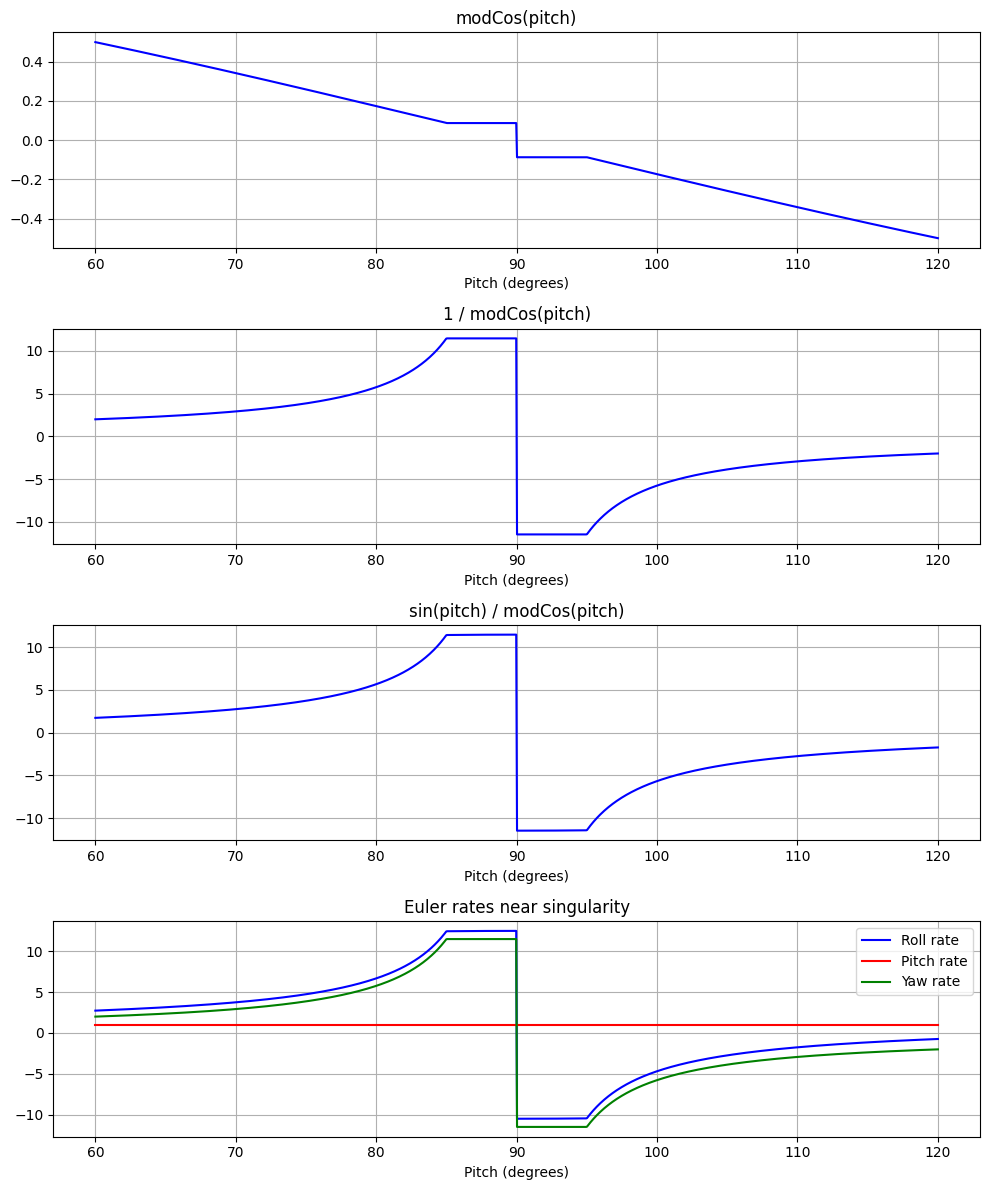

In [151]:
pitchDegArr = np.linspace(60, 120, 1024)
modCosArr = np.zeros(len(pitchDegArr))
gain1 = np.zeros(len(pitchDegArr))
gain2 = np.zeros(len(pitchDegArr))
rates = np.zeros((len(pitchDegArr), 3))
rollDeg = 0.0
w = np.array([1.0, 1.0, 1.0])
for i, pitchDeg in enumerate(pitchDegArr):
    pitchRad = math.radians(pitchDeg)
    modCosArr[i] = modCos(pitchRad)
    gain1[i] = 1.0 / modCosArr[i]
    gain2[i] = math.sin(pitchRad) / modCosArr[i]
    rates[i, :] = computeEulerRates(np.array([rollDeg, pitchDeg]), w)

fig, axes = plt.subplots(4, 1, figsize=(10, 12))

axes[0].plot(pitchDegArr, modCosArr, color="blue")
axes[0].set_title("modCos(pitch)")
axes[0].set_xlabel("Pitch (degrees)")

axes[1].plot(pitchDegArr, gain1, color="blue")
axes[1].set_title("1 / modCos(pitch)")
axes[1].set_xlabel("Pitch (degrees)")

axes[2].plot(pitchDegArr, gain2, color="blue")
axes[2].set_title("sin(pitch) / modCos(pitch)")
axes[2].set_xlabel("Pitch (degrees)")

axes[3].plot(pitchDegArr, rates[:, 0], label="Roll rate", color="blue")
axes[3].plot(pitchDegArr, rates[:, 1], label="Pitch rate", color="red")
axes[3].plot(pitchDegArr, rates[:, 2], label="Yaw rate", color="green")
axes[3].legend()
axes[3].set_title("Euler rates near singularity")
axes[3].set_xlabel("Pitch (degrees)")

for ax in axes:
    ax.grid(True)
plt.tight_layout()
plt.show()

## Estimate movement detection tolerance

In [152]:
stationaryChecker.computeTolerances(stationaryCaptures)

Acceleration norms:
	Mean = 9.803694
	Stdev = 0.078789 (tol = 0.236366)
	Stationary interval = [9.567327, 10.040060]
Gyroscope norms:
	Mean = 0.141652
	Stdev = 1.273801 (tol = 3.821403)
	Stationary interval = [-3.679752, 3.963055]


## Estimate angles with the complementary filter

There are two possible and equivalent orientations derived from the accelerometer measurements. However, just fusing with one of them naively can "screw up" the complementary filter orientation. This is because the gyro-derived orientation may be physically similar but numerically different. Thus, one orientation from the accelerometer must be picked:    

1. Solve orientation from gyroscope measurements.

2. Solve orientations from accelerometer measurements. 

3. Compute the "distance" between each acceleromenter orientation and the gyroscope orientation. This can be done with a p-norm, defined as:
    $$
    ||\bm{e}||_{p} = ||wrap(\bm{\Psi}_{wb, gyro} - \bm{\Psi}_{wb, acc})|| = (\sum_i |e_i|^p)^{1/p} 
    $$
    The Euclidean distance ($p=2$) was chosen, but the Manhattan distance ($p=1$) was also used previously. Hysteresis was also tested to avoid frequent branch switching, but it has been found out to be unnecessary in practice.
    Choose the orientation with the lower roll/pitch error for the accelerometer correction. Note that this is a simple heuristic, and it may fail in certain edge cases.

4. Fuse the gyroscope and accelerometer orientations as it's has been specified previously. 

Additionally, both orientations from acceleration become very ill-conditioned near $\theta = \pm 90^\circ$. In this case, within a tolerance band around those singularities the filter runs on gyroscope measurements only. Note that also gyro kinematic equations become ill-conditioned there, but at least divisions by zero are avoided. Both this phenomena compromise significantly the quality of the estimation on that zone. 

Sources: 

* https://en.wikipedia.org/wiki/Norm_(mathematics)#Examples

In [ ]:
# HYSTERESIS_TOL = 5.0  # deg


def complementaryFilterOrientation(
    seq,
    a,
    w,
    dt,
    stationaryChecker,
    alphaStationary,
    alphaMoving,
    gyroMethod="non-linear",
    accelBranch="both",
):
    signalLength = len(seq)

    # currentAccelBranch = 1
    predAnglesAccel1, predAnglesAccel2 = computeAccelAngleCandidates(a[0, :])
    predAngleCompl = np.zeros((signalLength, 2), dtype=np.float32)
    if accelBranch == "main" or accelBranch == "both":
        predAngleCompl[0, 0] = predAnglesAccel1[0]
        predAngleCompl[0, 1] = predAnglesAccel1[1]
        # currentAccelBranch = 1
    elif accelBranch == "alt":
        predAngleCompl[0, 0] = predAnglesAccel2[0]
        predAngleCompl[0, 1] = predAnglesAccel2[1]
        # currentAccelBranch = 2

    predAngleAccel = np.zeros((signalLength, 2), dtype=np.float32)

    predYawAngleGyro = np.zeros(signalLength, dtype=np.float32)
    eulerRates = np.zeros(3, dtype=np.float32)
    if gyroMethod == "non-linear":
        predYawAngleGyro = gyroOnlyOrientationNonLinearTransform(a, w, dt)[:, 2]
        eulerRates = computeEulerRates(predAngleCompl[0, :], w[0, :])[:2]
    elif gyroMethod == "simple":
        predYawAngleGyro = gyroOnlyOrientationDirectIntegration(a, w, dt)[:, 2]

    for i in range(1, signalLength):
        predAngleGyro = np.zeros(2, dtype=np.float32)
        if gyroMethod == "non-linear":
            prevEulerRates = eulerRates
            eulerRates = computeEulerRates(predAngleCompl[i - 1, :], w[i, :])[:2]
            predAngleGyro = integrateTrapezoid(
                predAngleCompl[i - 1, :], prevEulerRates, eulerRates, dt
            )
        elif gyroMethod == "simple":
            predAngleGyro = integrateEuler(predAngleCompl[i - 1, :], w[i, :2], dt)

        predAnglesAccel1, predAnglesAccel2 = computeAccelAngleCandidates(a[i, :])
        if accelBranch == "main":
            predAngleAccel[i, :] = predAnglesAccel1
        elif accelBranch == "alt":
            predAngleAccel[i, :] = predAnglesAccel2
        elif accelBranch == "both":
            error1 = angleDistanceDegrees(predAnglesAccel1, predAngleGyro)
            error2 = angleDistanceDegrees(predAnglesAccel2, predAngleGyro)

            # if currentAccelBranch == 1:
            #     if error2 + HYSTERESIS_TOL < error1:
            #         currentAccelBranch = 2
            #         predAngleAccel[i, :] = predAnglesAccel2
            #     else:
            #         predAngleAccel[i, :] = predAnglesAccel1
            # elif currentAccelBranch == 2:
            #     if error1 + HYSTERESIS_TOL < error2:
            #         currentAccelBranch = 1
            #         predAngleAccel[i, :] = predAnglesAccel1
            #     else:
            #         predAngleAccel[i, :] = predAnglesAccel2

            if error1 < error2:
                predAngleAccel[i, :] = predAnglesAccel1
            else:
                predAngleAccel[i, :] = predAnglesAccel2

        predAngleAccel[i, :] = np.array(
            [
                predAngleGyro[0] + wrapDegrees(predAngleAccel[i, 0] - predAngleGyro[0]),
                predAngleGyro[1] + wrapDegrees(predAngleAccel[i, 1] - predAngleGyro[1]),
            ]
        )

        wrappedPredPitchGyro = wrapDegrees(predAngleGyro)[1]
        if (
            90 - SINGULARITY_SAFETY_TOL
            < wrappedPredPitchGyro
            < 90 + SINGULARITY_SAFETY_TOL
        ) or (
            -90 - SINGULARITY_SAFETY_TOL
            < wrappedPredPitchGyro
            < -90 + SINGULARITY_SAFETY_TOL
        ):
            predAngleCompl[i, :] = predAngleGyro
        elif stationaryChecker.isStationarySample(*a[i, :], *w[i, :]):
            predAngleCompl[i, :] = (
                alphaStationary * predAngleGyro
                + (1 - alphaStationary) * predAngleAccel[i, :]
            )
        else:
            predAngleCompl[i, :] = (
                alphaMoving * predAngleGyro + (1 - alphaMoving) * predAngleAccel[i, :]
            )

    return (
        predAngleAccel,
        np.hstack((predAngleCompl, predYawAngleGyro.reshape(-1, 1))),
    )


def angleDistanceDegrees(candidate, prediction):
    errors = np.array(
        [
            wrapDegrees(candidate[0] - prediction[0]),
            wrapDegrees(candidate[1] - prediction[1]),
        ]
    )
    return np.linalg.norm(errors)

In [187]:
# Candidates and prediction within range [-180, 180], exactly matching one candidate
cand1 = np.array([0.0, -45.0])
cand2 = np.array([-180.0, -135.0])
pred = np.array([0.0, -45.0])
assert math.isclose(angleDistanceDegrees(cand1, pred), 0.0)
assert angleDistanceDegrees(cand2, pred) > 0

# Candidates and prrediction within range [-180, 180], close to one candidate
cand1 = np.array([0.0, -45.0])
cand2 = np.array([-180.0, -135.0])
pred = np.array([1.0, -44.0])
assert angleDistanceDegrees(cand1, pred) < angleDistanceDegrees(cand2, pred)

# Candidates within [-180, 180], prediction out of the range [-180, 180], exactly matching one candidate
cand1 = np.array([0.0, -45.0])
cand2 = np.array([-180.0, -135.0])
pred = np.array([360.0, 315.0])
assert math.isclose(angleDistanceDegrees(cand1, pred), 0.0)
assert angleDistanceDegrees(cand2, pred) > 0

# Candidates within [-180, 180], prediction out of the range [-180, 180], close to one candidate
cand1 = np.array([0.0, -45.0])
cand2 = np.array([-180.0, -135.0])
pred = np.array([361.0, 314.0])
assert angleDistanceDegrees(cand1, pred) < angleDistanceDegrees(cand2, pred)

# Prediction equidistant from both candidates (must break tie somehow)
cand1 = np.array([0.0, -45.0])
cand2 = np.array([-180.0, -135.0])
pred = np.array([-90.0, -90.0])
assert math.isclose(
    angleDistanceDegrees(cand1, pred), angleDistanceDegrees(cand2, pred)
)

# Notice that the candidates are always within the range [-180, 180]. No test cases are needed for candidates out of this range.

## Grid search for filter parameters

Run the filter with different combinations of $\alpha_{stationary}$ and $\alpha_{moving}$ for later evaluation when gravity removal is applied to the linear acceleration. Export results to .csv files.

In [188]:
alphaStationaryArr = [0.75, 0.80, 0.85, 0.90, 0.95]
alphaMovingArr = [0.95, 0.975, 0.99]
for ast in alphaStationaryArr:
    for amv in alphaMovingArr:
        for capturePath in [
            *stationaryCaptures,
            *simpleRotationsCaptures,
            *realExerciseCaptures,
        ]:
            seq, a, w = reader.read(capturePath)
            transformSensorToBodyFrame(a, w)
            _, complementaryAngles = complementaryFilterOrientation(
                seq,
                a,
                w,
                dt,
                stationaryChecker,
                ast,
                amv,
                gyroMethod="non-linear",
                accelBranch="both",
            )

            filename = f"./output/ast={ast:.3f}-amv={amv:.3f}/{capturePath.split('/')[-1].split('.')[0]}-or-compl.csv"
            writer.writeWithOrientation(filename, seq, a, w, complementaryAngles)

## Plot results as a time-series for a specific capture, $\alpha_{stationary}$ and $\alpha_{moving}$ 

In [189]:
from matplotlib.ticker import MultipleLocator

SMALL_ANGLE_RANGE_THRESHOLD = 3


def plotEulerAngles(
    seq,
    gyroAngles,
    accelAngles,
    complAngles,
    stationaryIntervals,
    capturePath,
):
    def configGraph(upperBound, lowerBound, axis, title):
        if lowerBound < -180:
            axis.axhline(-180, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if lowerBound < -90:
            axis.axhline(-90, color="black", linestyle="-", linewidth=2.0, zorder=0)
        axis.axhline(0, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if upperBound > 90:
            axis.axhline(90, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if upperBound > 180:
            axis.axhline(180, color="black", linestyle="-", linewidth=2.0, zorder=0)
        axis.set_ylabel("Angle (degrees)")
        if upperBound - lowerBound > SMALL_ANGLE_RANGE_THRESHOLD:
            axis.yaxis.set_major_locator(MultipleLocator(15))

        axis.grid(True, which="both", linestyle="-", alpha=0.75)
        axis.set_xlabel("Sequence number")
        axis.set_title(title)

        for lower, upper in stationaryIntervals:
            axis.axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)

        axis.legend()

    lowerBoundRoll = min(
        accelAngles[:, 0].min(),
        gyroAngles[:, 0].min(),
        complAngles[:, 0].min(),
    )
    upperBoundRoll = max(
        accelAngles[:, 0].max(),
        gyroAngles[:, 0].max(),
        complAngles[:, 0].max(),
    )
    lowerBoundPitch = min(
        accelAngles[:, 1].min(), gyroAngles[:, 1].min(), complAngles[:, 1].min()
    )
    upperBoundPitch = max(
        accelAngles[:, 1].max(), gyroAngles[:, 1].max(), complAngles[:, 1].max()
    )
    lowerBoundYaw = gyroAngles[:, 2].min()
    upperBoundYaw = gyroAngles[:, 2].max()

    fig, axes = plt.subplots(3, 1, figsize=(16, 16))

    axes[0].plot(seq, accelAngles[:, 0], label="Acceleration-based", color="blue")
    axes[0].plot(seq, gyroAngles[:, 0], label="Gyroscope-based", color="green")
    axes[0].plot(seq, complAngles[:, 0], label="Complementary filter", color="red")
    configGraph(upperBoundRoll, lowerBoundRoll, axes[0], "Roll angle")

    axes[1].plot(seq, accelAngles[:, 1], label="Acceleration-based", color="blue")
    axes[1].plot(seq, gyroAngles[:, 1], label="Gyroscope-based", color="green")
    axes[1].plot(seq, complAngles[:, 1], label="Complementary filter", color="red")
    configGraph(upperBoundPitch, lowerBoundPitch, axes[1], "Pitch angle")

    axes[2].plot(seq, gyroAngles[:, 2], label="Gyroscope-based", color="green")
    configGraph(upperBoundYaw, lowerBoundYaw, axes[2], "Yaw angle")

    fig.suptitle(
        f"Euler angles estimation: {capturePath}\n(stationary intervals highlighted in gray)"
    )
    plt.tight_layout()
    plt.show()

In [196]:
# Change index to visualize different captures
# capturePath = stationaryCaptures[0]
capturePath = simpleRotationsCaptures[2]
# capturePath = realExerciseCaptures[-2]
alphaStationary = 0.75
alphaMoving = 0.95
seq, a, w = reader.read(capturePath)
transformSensorToBodyFrame(a, w)
stationaryIntervals = stationaryChecker.findStationaryIntervals(seq, a, w)

### Classical formula

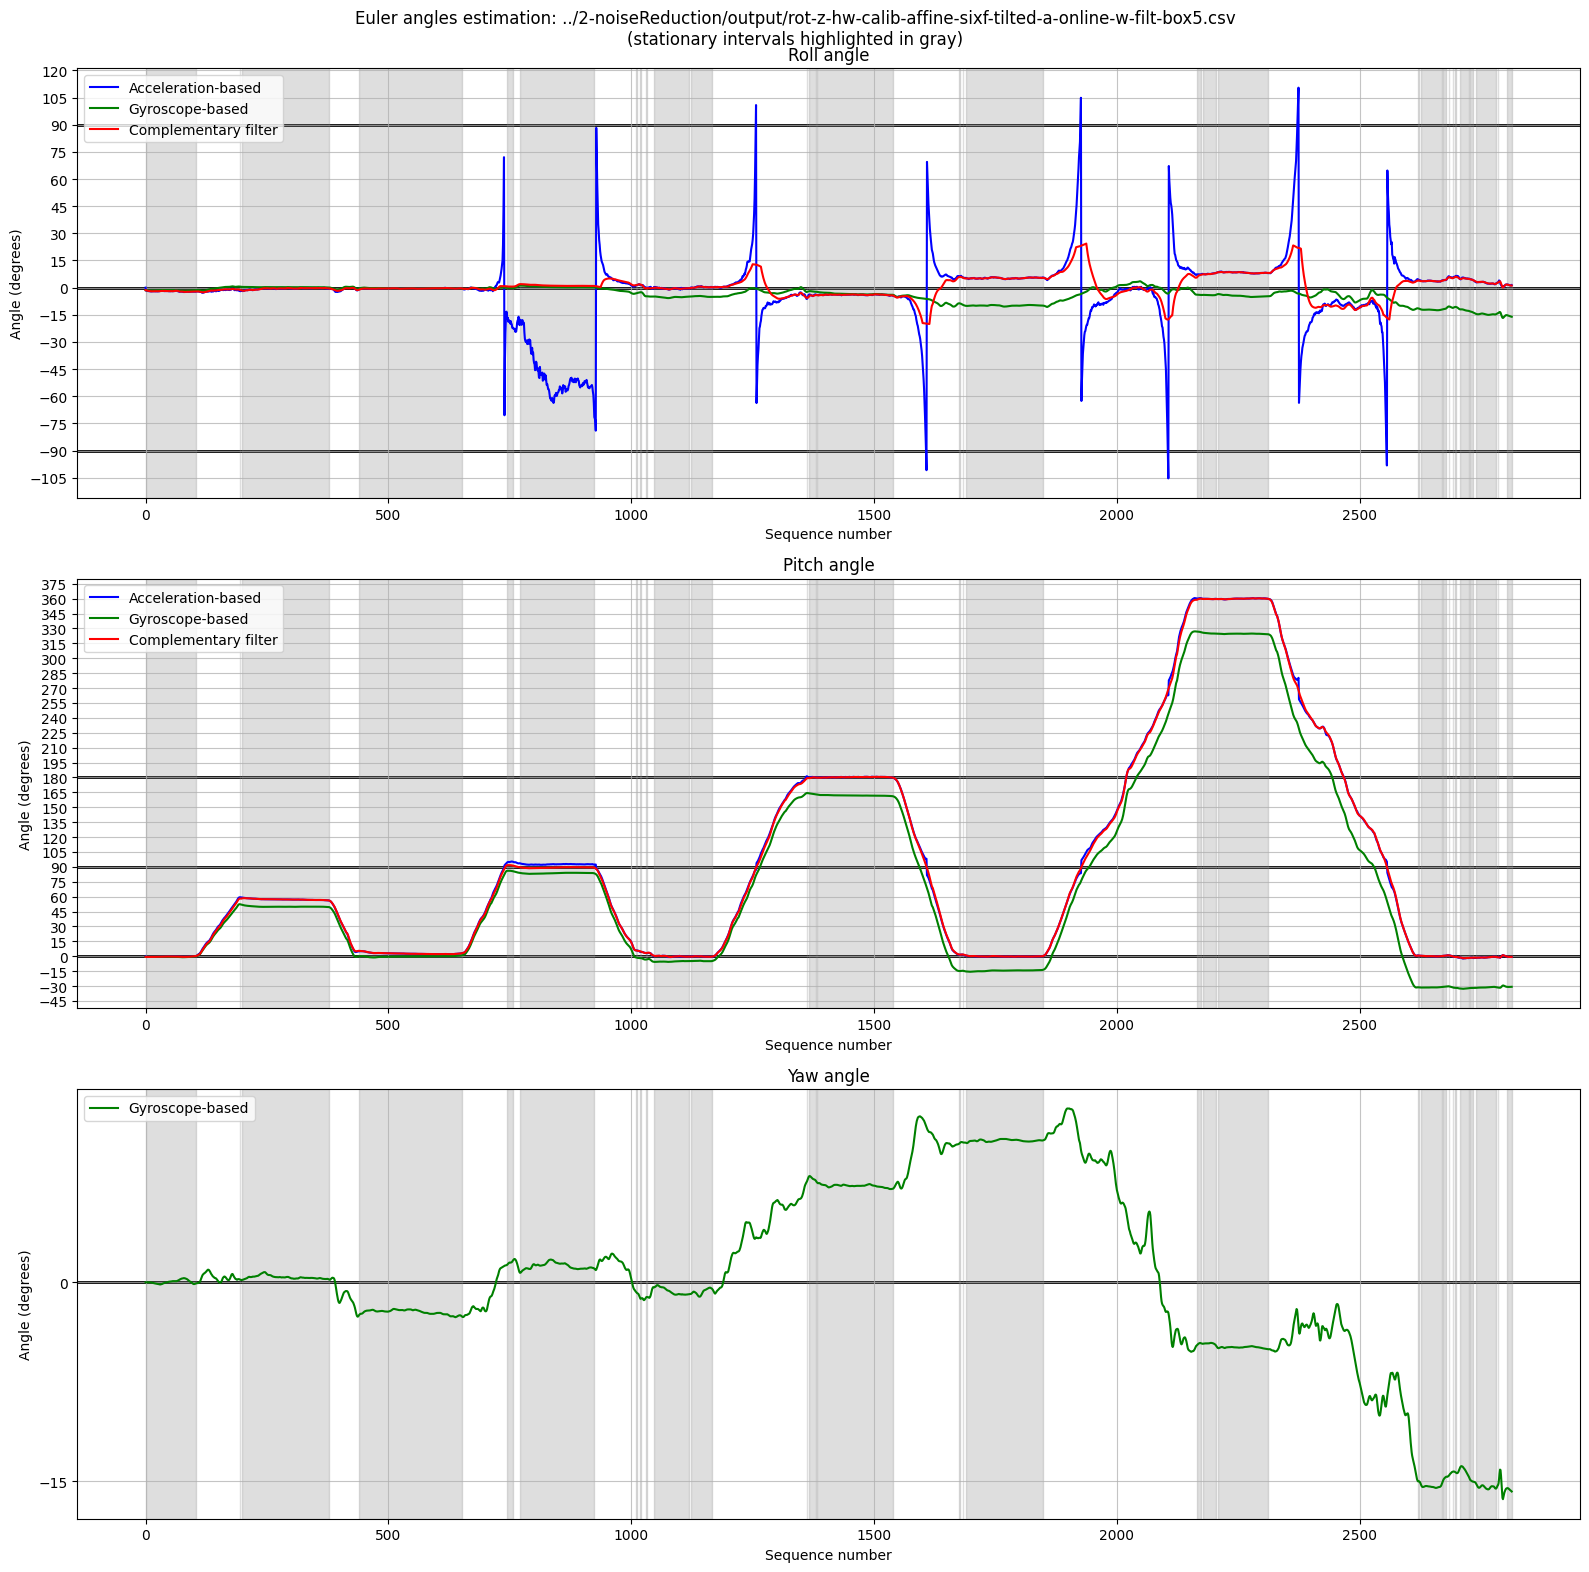

In [197]:
gyroAngles = gyroOnlyOrientationDirectIntegration(a, w, dt)
accelAngles, complementaryAngles = complementaryFilterOrientation(
    seq,
    a,
    w,
    dt,
    stationaryChecker,
    alphaStationary,
    alphaMoving,
    gyroMethod="simple",
    accelBranch="both",
)
plotEulerAngles(
    seq, gyroAngles, accelAngles, complementaryAngles, stationaryIntervals, capturePath
)

### Corrected formula

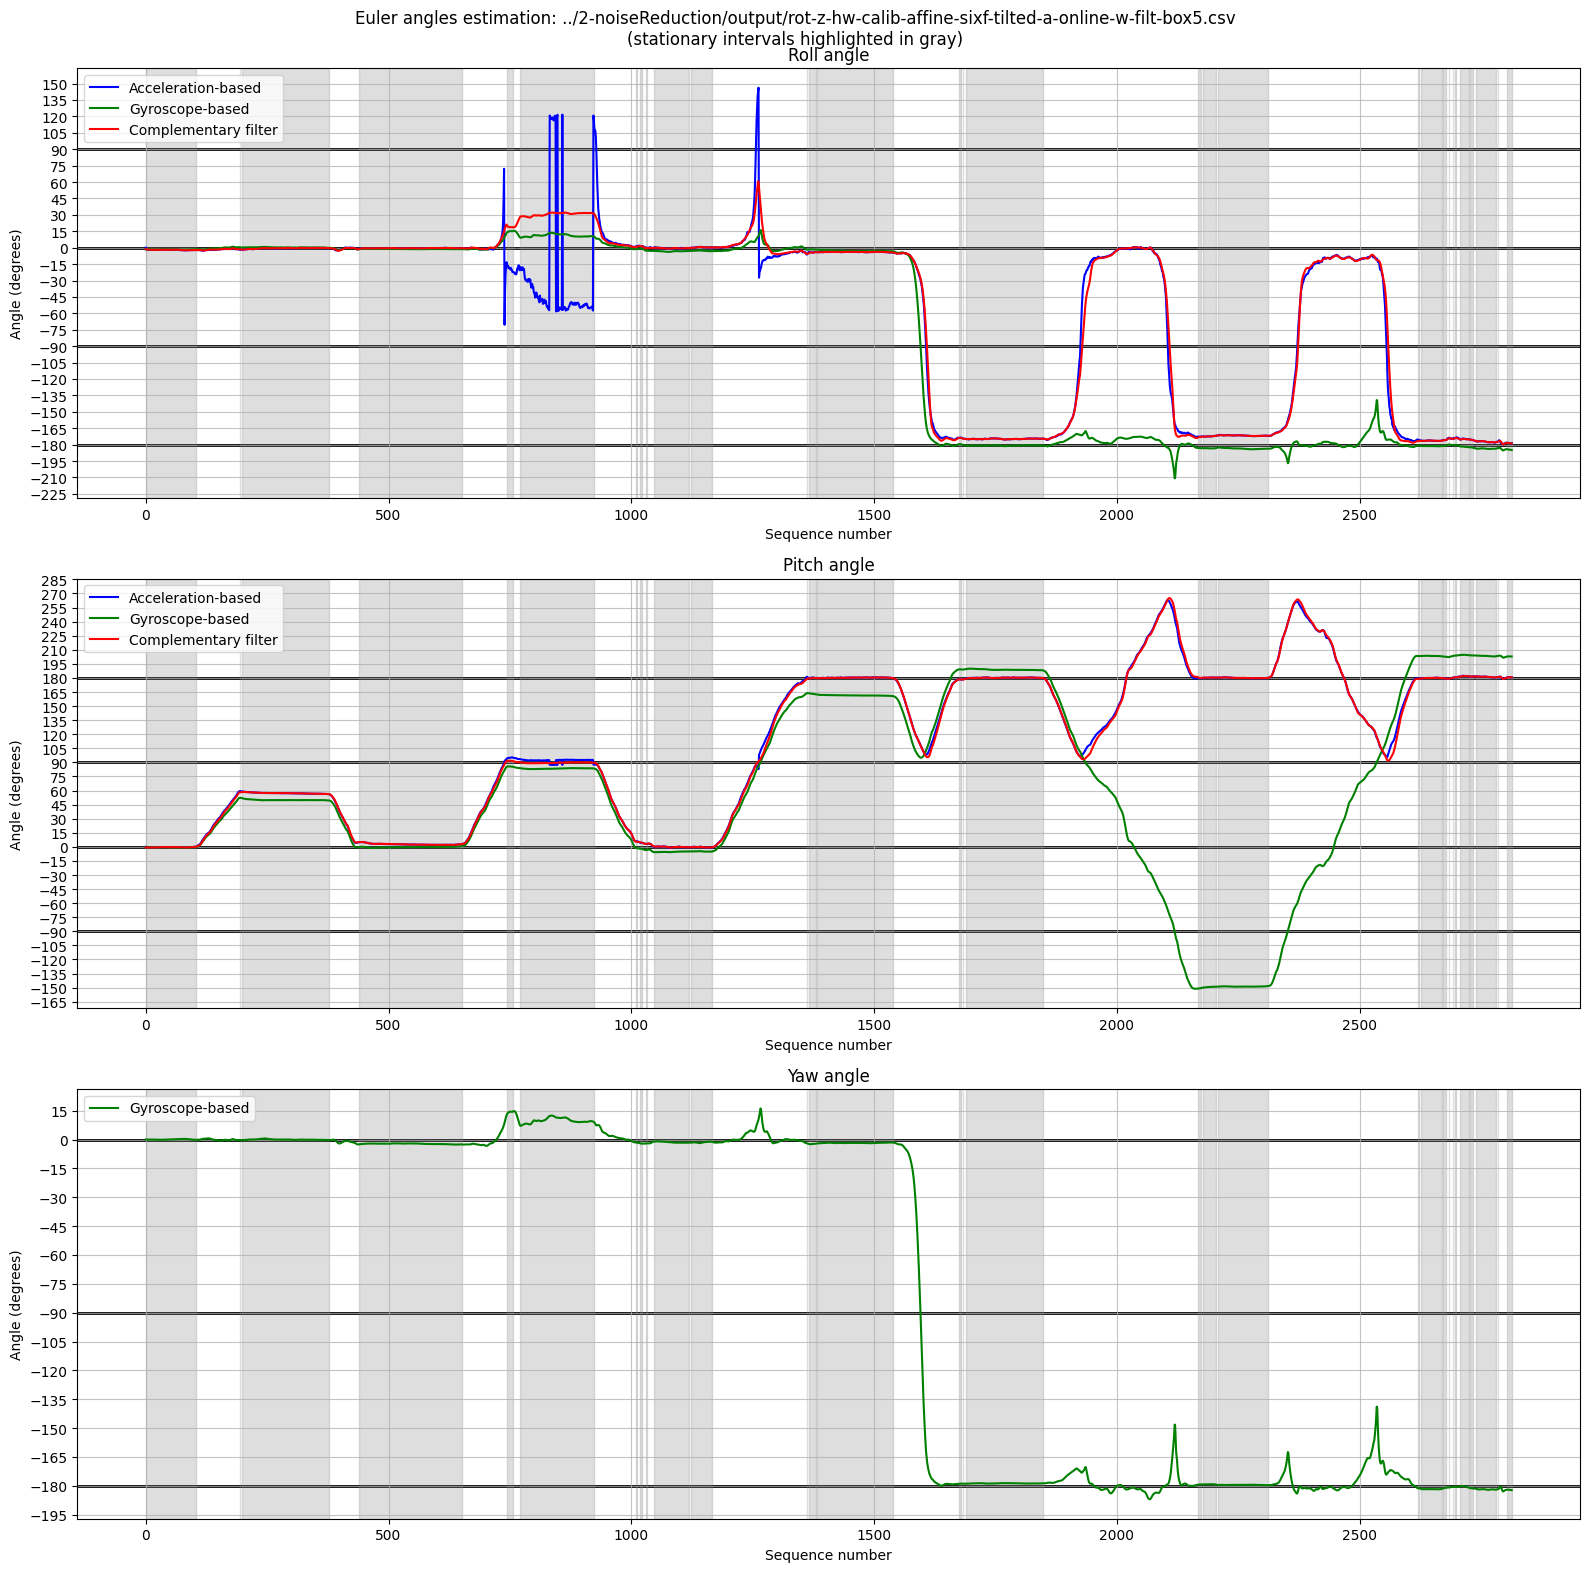

In [198]:
gyroAngles = gyroOnlyOrientationNonLinearTransform(a, w, dt)
accelAngles, complementaryAngles = complementaryFilterOrientation(
    seq,
    a,
    w,
    dt,
    stationaryChecker,
    alphaStationary,
    alphaMoving,
    gyroMethod="non-linear",
    accelBranch="both",
)
plotEulerAngles(
    seq, gyroAngles, accelAngles, complementaryAngles, stationaryIntervals, capturePath
)

# Conclusion

Stationary, simple rotations and real exercise captures have been validated with video recordings and rough angle measurements with a protractor. Estimation on first sight works decently, but as it has been seen downstream in the pipeline, the accuracy is not enough.

There have been many limitations and implementation difficulties:

* The singularities at $\theta = \pm 90^\circ$ are especially problematic, appear everywhere (both on the accelerometer and gyroscope) and can't be fully mitigated.

* The workarounds discussed earlier (protection of atan2 against noise, clamped cosine, orientation decision, varying filter parameter, hysteresis) are not entirely clean and add complexity and computation time to the filter, which goes against the goal of simplicity that was originally intended. 

* The classical complementary filter itself is not entirely right mathematically regarding the gyroscope-based orientation. I get the impression that it wasn't designed to accomodate for free motion in all directions.

A future iteration must consider a more advanced sensor fusion algorithm (Mahony, Madgwick, Kalman) and representation of orientation with quaternions.